# Lab 2: Bifurcations

## Problem 1 (4 points total)

You have been given signals of human brain activity obtained using an EEG.

The signal is received in two states - first, the subject solves a mathematical problem in his mind, then, having solved the problem, he stops thinking about anything :).

Your task is to find the bifurcation point in the brain activity of the subject - that is, the point at which the signal qualitatively changes its behavior.

In this case, it will be the point in time at which the person stopped solving the problem.

During this problem, you will be able to practice using Newton's method and searching for bifurcations on a one-dimensional problem, which will be very useful in the second task, which will be more difficult.

### Libraries

You are not allowed to use any other Python libraries except the ones listed below :(

In [1]:
import os.path as osp
from matplotlib import pyplot as plt
import numpy as np
from numba import njit
from scipy.stats import gaussian_kde
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import interp1d

import mne
from tqdm.auto import trange, tqdm
from warnings import filterwarnings
filterwarnings('ignore')

import joblib # <-- Added this. Sorry, I really do not want to wait unnecessarily long...

### Read data

In [2]:
path = osp.join("Brain_EEG.npy")
power = np.load(path, allow_pickle=True)
sample_freq = 500.
print(f"Signal sampling frequency={sample_freq} Hz")
power.shape

Signal sampling frequency=500.0 Hz


(700, 79694)

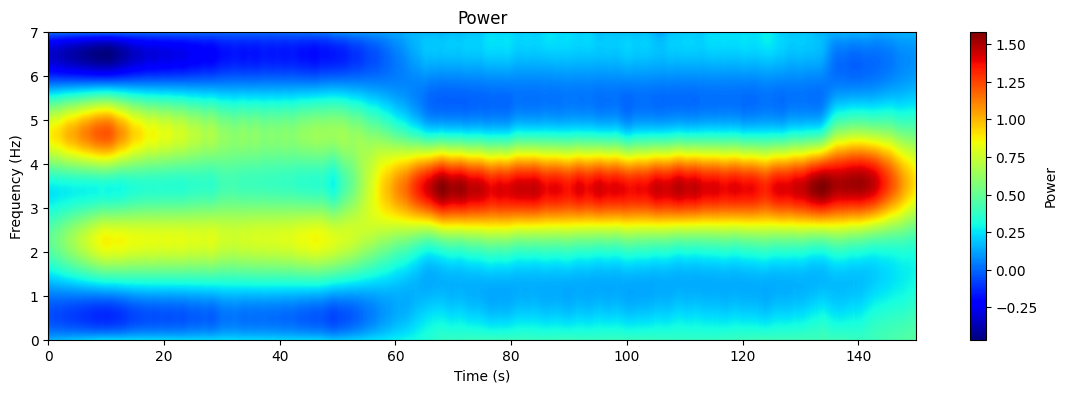

In [3]:
plt.figure(figsize = (14, 4))
plt.title('Power')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
im = plt.imshow(power, aspect = 'auto', extent = [0, 150, 0, 7], cmap = 'jet')
plt.colorbar(im, ax = plt.gca()).set_label('Power')

### Problem 1.1 Let's look at the signal (1 point)

1. Implement a method for calculating the mean and variance of the signal frequency

2. Plot the signal power in the frequency domain, calculate the average and the variance of its frequency. To make the signal smoother, we will consider a window in the time domain, and average the signal power over time in this window. The choice of window width is yours.

In [4]:
WINDOW_SIZE = 100

In [5]:
@njit # you can remove, but it will work slower
def spectral_mean_std(
    omega_grid: np.ndarray, # (n_frequencies,)
    power_1d: np.ndarray, # (n_frequencies,)
):
    prob_distr = power_1d / np.sum(power_1d)
    mean = np.sum(omega_grid * prob_distr)

    disp = np.sum(prob_distr * ((omega_grid - mean) ** 2))
    std = np.sqrt(disp)
    return mean, std

Mean frequency: 3.59 Hz
Std (spectral width): 0.85 Hz


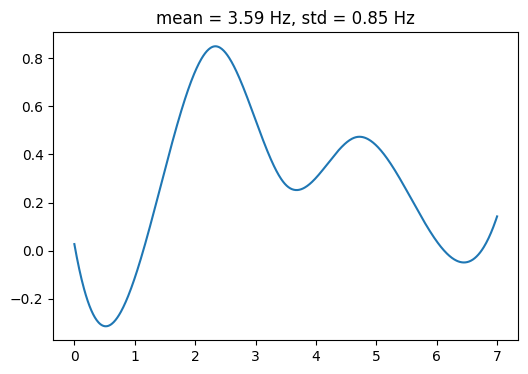

In [6]:
def plot_averaged_signal(
    power_1d: np.ndarray, # (n_frequencies, n_samples)
    window_size: int,
    ax,
    window_start: int = 0
):
    # average the signal power over time in this window
    avg_power_1d = power_1d[:, window_start:window_start + window_size].mean(axis = 1)

    omega_grid = np.linspace(0, 7, power_1d.shape[0])
    mean, std = spectral_mean_std(omega_grid, avg_power_1d)

    print(f'Mean frequency: {mean:.2f} Hz')
    print(f'Std (spectral width): {std:.2f} Hz')

    ax.plot(omega_grid, avg_power_1d)
    ax.set_title(f"mean = {mean:.2f} Hz, std = {std:.2f} Hz")

fig, ax = plt.subplots(1, 1, figsize = (6, 4))
plot_averaged_signal(power, WINDOW_SIZE, ax)

### Problem 1.2  Search for signal parameters using the Newton method (1 point)

As you can see from your graph above (you can move the window to see how the signal behaves), the brain activity signal in the frequency domain resembles a combination of one or two Gaussians. Therefore, we will model it exclusively in this way.

In particular, your task is to take two Gaussians with averages $\omega_1, \omega_2$, and find these two parameters that minimize the deviation of the simulated signal from the real one using the Newton method. The variance for each Gaussian can be taken, for example, equal to the variance of the entire signal.

Your tasks:

1. Consider functional - square of the norm ($L_2 - norm$) of the deviation of model signal from the real one.
$$
    ||f(x)||_2^2 = \int_a^b f^2(x) \: dx, \quad x \in [a,b]
$$
$\quad$ In our problem, this functional is essentially just a function of two variables $\omega_1, \omega_2$, and for them it is an integral with two parameters. Accordingly, write down (in words or $\LaTeX$ formula) the necessary first-order local minimum conditions for it (relative to $\omega_1, \omega_2$).

2. These two conditions will be the boundary conditions for our task. Now, using Newton's method, find the frequencies that minimize the functional for our signal model

P.S. In order not to look for a constant by which the signal power is shifted relative to zero, you can simply subtract the average of its values at the edges from the signal.

#### You need to implement the Newton's method and all the necessary functions yourself! To do this, from the libraries you can use only `numpy`, `numba`.

First, to make sure that your implementation is correct, find the correct frequencies for the signal for which you know them.

$$ ||f(x)||_2^2 = \int_a^b f^2(x) \: dx, \quad x \in [a,b] $$

In our case, the signal is discrete. So, the functional is as follows:
$$ F(\omega_1, \omega_2) = ||f(x)||_2^2 = \sum_{i = 1}^{n} (y_{pred}[i] - y_{true}[i])^2 \to min, \quad y_{pred}[i] = \dfrac{1}{\sqrt{2 \pi} \sigma} e ^ {- \dfrac{(x_i - \omega_1)^2}{2 \sigma^2}} + \dfrac{1}{\sqrt{2 \pi} \sigma} e ^ {- \dfrac{(x_i - \omega_2)^2}{2 \sigma^2}} $$

Boundary conditions:
$$ \dfrac{\partial F}{\partial \omega_1} = \sum_{i = 1}^{n} 2 (y_{pred}[i] - y_{true}[i]) \dfrac{\partial y_{pred}[i]}{\partial \omega_1} = 0 $$

$$ \dfrac{\partial F}{\partial \omega_2} = \sum_{i = 1}^{n} 2 (y_{pred}[i] - y_{true}[i]) \dfrac{\partial y_{pred}[i]}{\partial \omega_2} = 0 $$

Derivatives of the Gaussian:
$$ \dfrac{\partial y_{pred}[i]}{\partial \omega_1} = \dfrac{1}{\sqrt{2 \pi} \sigma} e ^ {- \dfrac{(x_i - \omega_1)^2}{2 \sigma^2}} \dfrac{\partial - \dfrac{(x_i - \omega_1)^2}{2 \sigma^2}}{\partial \omega_1} = G(x_i, \omega_1) \dfrac{x_i - \omega_1}{\sigma ^ 2} $$

$$ \dfrac{\partial y_{pred}[i]}{\partial \omega_2} = G(x_i, \omega_2) \dfrac{x_i - \omega_2}{\sigma ^ 2} $$

In [7]:
@njit
def normalized_gaussian(omega, omega0, sigma):
    coef = 1.0 / (np.sqrt(2 * np.pi) * sigma)
    return coef * np.exp(-0.5 * ((omega - omega0) / sigma)**2)

@njit
def normalized_gaussian_derivative(omega, omega0, sigma):
    return normalized_gaussian(omega, omega0, sigma) * (omega - omega0) / (sigma ** 2)

@njit
def model_signal(omega, omega1, omega2, sigma):
    return normalized_gaussian(omega, omega1, sigma) + normalized_gaussian(omega, omega2, sigma)

@njit
def compute_F(omega_grid, y_true, omega1, omega2, sigma):
    """
    Calculte residuals
    """
    diff = model_signal(omega_grid, omega1, omega2, sigma) - y_true
    c1 = np.sum(2 * diff * normalized_gaussian_derivative(omega_grid, omega1, sigma))
    c2 = np.sum(2 * diff * normalized_gaussian_derivative(omega_grid, omega2, sigma))
    return np.array([ c1, c2 ])

def approximate_jacobian(func, omega1, omega2, dx, *args):
    """
    Calculate approximation of Jacobian
    """
    F0 = func(omega1, omega2, *args)
    F1 = func(omega1 + dx, omega2, *args)
    F2 = func(omega1, omega2 + dx, *args)
    return np.vstack([ (F1 - F0) / dx, (F2 - F0) / dx ]).T

def newton_solver(omega_grid, y_true, omega1_init, omega2_init, sigma, 
                  dx=1e-3, tol=1e-6, max_iter=1_000, verbose=True):
    """
    Implement Newton method to find optimal frequencies omega1, omega2 
    """
    omegas = np.array([ omega1_init, omega2_init ])
    for num_iter in range(max_iter):
        F = compute_F(omega_grid, y_true, omegas[0], omegas[1], sigma)
        func = lambda o1, o2: compute_F(omega_grid, y_true, o1, o2, sigma)
        dF = approximate_jacobian(func, omegas[0], omegas[1], dx)

        if np.linalg.norm(F) < tol:
            if verbose:
                print(f"Converged on iteration {num_iter} with F = {F}")
            return omegas[0], omegas[1], dF
        if np.linalg.det(dF) == 0:
            if verbose:
                print(f"Failed to converge on iteration {num_iter} with F = {F}")
            return omegas[0], omegas[1], dF
            
        omegas = omegas - (np.linalg.inv(dF) @ F.reshape(-1, 1)).squeeze()
        if verbose:
            print(f"Iteration {num_iter}: omega1 = {omegas[0]:.3f}, omega2 = {omegas[1]:.3f}, F = {F}")

    return omegas[0], omegas[1], dF

Iteration 0: omega1 = 1.742, omega2 = 5.225, F = [ 55.30977976 -55.30977976]
Iteration 1: omega1 = 2.040, omega2 = 4.974, F = [-54.41647698  48.21799823]
Iteration 2: omega1 = 2.000, omega2 = 5.000, F = [ 8.91775802 -5.81575361]
Iteration 3: omega1 = 2.000, omega2 = 5.000, F = [-0.02471068  0.0014496 ]
Converged on iteration 4 with F = [2.66112843e-08 1.19195207e-07]
Omega 1:  2.000000000119197
Omega 2:  5.000000000529176


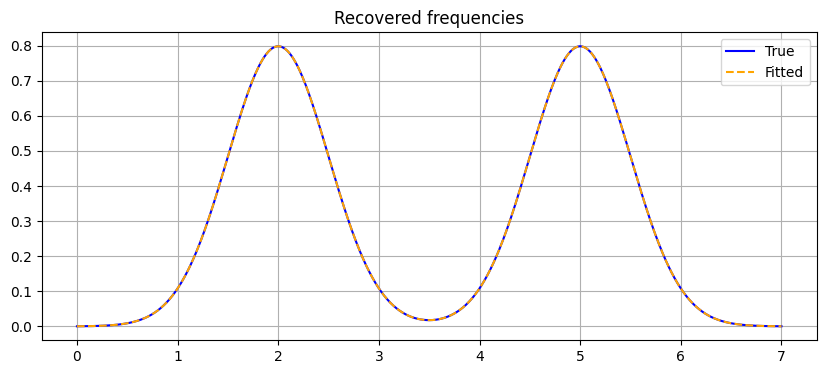

In [8]:
sigma = 0.5
omega_grid = np.linspace(0, 7, 700)

y_true = model_signal(omega_grid, 2, 5, sigma)
omega1, omega2, _ = newton_solver(omega_grid, y_true, 0, 7, sigma)
y_pred = model_signal(omega_grid, omega1, omega2, sigma)

print('Omega 1: ', omega1)
print('Omega 2: ', omega2)

plt.figure(figsize = (10, 4))
plt.grid()
plt.title("Recovered frequencies")
plt.plot(omega_grid, y_true, label = 'True', color = 'blue')
plt.plot(omega_grid, y_pred, label = 'Fitted', color = 'orange', linestyle = '--')
plt.legend()

#### Now for real signal

Iteration 0: omega1 = 2.387, omega2 = 4.636, F = [-1.6601191   6.63075542]
Iteration 1: omega1 = 2.384, omega2 = 4.628, F = [0.10018657 0.26448659]
Iteration 2: omega1 = 2.384, omega2 = 4.628, F = [6.11586919e-06 1.38854513e-03]
Converged on iteration 3 with F = [3.69810783e-08 7.12120540e-07]


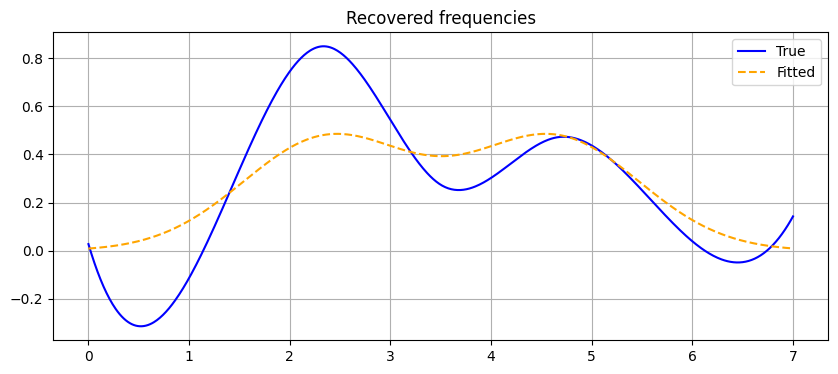

In [9]:
y_true = power[:, :WINDOW_SIZE].mean(axis=1)
omega_grid = np.linspace(0, 7, power.shape[0])
_, sigma = spectral_mean_std(omega_grid, y_true)
omega1, omega2, _ = newton_solver(omega_grid, y_true, 2.4, 4.8, sigma)
y_pred = model_signal(omega_grid, omega1, omega2, sigma)

plt.figure(figsize = (10, 4))
plt.grid()
plt.title("Recovered frequencies")
plt.plot(omega_grid, y_true, label = 'True', color = 'blue')
plt.plot(omega_grid, y_pred, label = 'Fitted', color = 'orange', linestyle = '--')
plt.legend()

### Problem 1.3 (1 point)

In Newton's method, you considered the Jacobian approximation. Now, moving the window along the signal, plot the absolute values of determinants of the found Jacobians. Again, use only `numpy`, `numba`

  0%|          | 0/79594 [00:00<?, ?it/s]

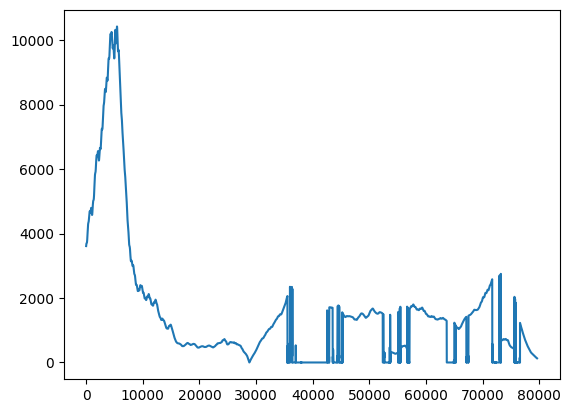

In [10]:
jacobian_dets = []
for i in trange(power.shape[1] - WINDOW_SIZE):
    y_true = power[:, i:i + WINDOW_SIZE].mean(axis=1)
    omega_grid = np.linspace(0, 7, power.shape[0])
    _, sigma = spectral_mean_std(omega_grid, y_true)
    _, _, jacobian = newton_solver(omega_grid, y_true, 2.4, 4.8, sigma, verbose = False)
    jacobian_dets.append(np.abs(np.linalg.det(jacobian)))
    
plt.plot(list(range(power.shape[1] - WINDOW_SIZE)), jacobian_dets)

#### As you can see, the determinant reaches zero for the first time at some point.

(not exactly zero, but since we are approximating the Jacobian, we can assume that at the moment when the determinant reached the lowest value and began to increase back, it actually reached zero)

This point will be the bifurcation point, according to the theory of bifurcations.

In [11]:
bifurcation_point = np.argmin(jacobian_dets[:30000])
bifurcation_point

28809

#### Problem 1.4 Plot the signal power in the frequency domain before, at, and after the bifurcation point. Draw conclusions. (1 point)

Mean frequency: 3.92 Hz
Std (spectral width): 1.13 Hz
Mean frequency: 3.75 Hz
Std (spectral width): 1.18 Hz
Mean frequency: 3.74 Hz
Std (spectral width): 1.33 Hz


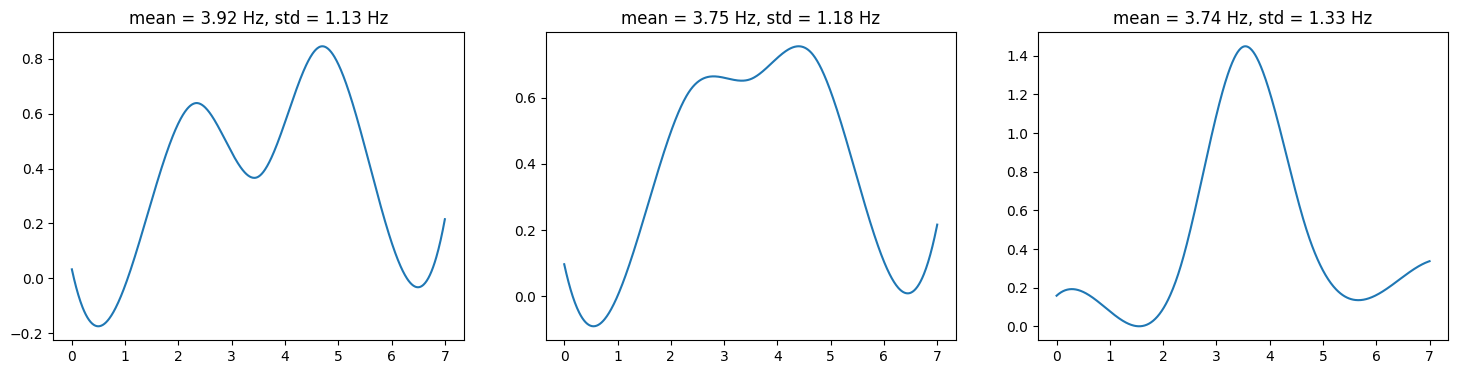

In [12]:
fig, axes = plt.subplots(1, 3, figsize = (18, 4))

plot_averaged_signal(power, WINDOW_SIZE, axes[0], 25000)
plot_averaged_signal(power, WINDOW_SIZE, axes[1], int(bifurcation_point - WINDOW_SIZE / 2))
plot_averaged_signal(power, WINDOW_SIZE, axes[2], 35000)

  0%|          | 0/79594 [00:00<?, ?it/s]

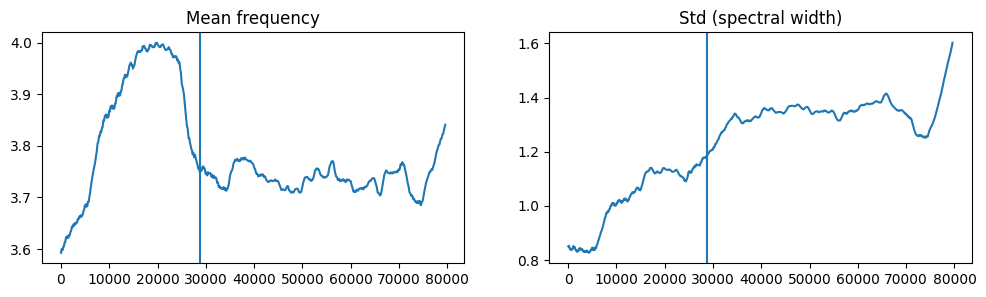

In [13]:
means, stds = [], []
for i in trange(power.shape[1] - WINDOW_SIZE):
    avg_power_1d = power[:, i:i + WINDOW_SIZE].mean(axis = 1)
    mean, std = spectral_mean_std(np.linspace(0, 7, avg_power_1d.shape[0]), avg_power_1d)
    means.append(mean)
    stds.append(std)

fig, axes = plt.subplots(1, 2, figsize = (12, 3))

axes[0].plot(list(range(power.shape[1] - WINDOW_SIZE)), means)
axes[0].set_title("Mean frequency")
axes[0].axvline(bifurcation_point)

axes[1].plot(list(range(power.shape[1] - WINDOW_SIZE)), stds)
axes[1].set_title("Std (spectral width)")
axes[1].axvline(bifurcation_point)

There are clear qualitative differences in the signal's behavior before and after the bifurcation.
<table>
    <tr>
        <th></th>
        <th>Before the bifurcation</th>
        <th>After the bifurcation</th>
    </tr>
    <tr>
        <td>"Appearance" of the signal power</td>
        <td>Two clear peaks</td>
        <td>One peak</td>
    </tr>
    <tr>
        <td>Peak absolute value of the signal's power</td>
        <td>0.8</td>
        <td>1.4</td>
    </tr>
    <tr>
        <td>Mean power of the signal</td>
        <td>Monotonically increases from 3.6 to 4.0, then drops right before the bifurcation</td>
        <td>Comparatively constant with slight fluctuations around 3.75</td>
    </tr>
    <tr>
        <td>Standard deviation of the signal power</td>
        <td>Increases from 0.8 to 1.2</td>
        <td>Relatively constant around 1.35</td>
    </tr>
</table>

These results are consistent with the power plot we saw previously (before problem 1.1). In the beginning, there are two "green lines" that stand out from the rest with power around 0.8. In the end, on the other hand, there is one "red line", indicating the only peak with the power reaching 1.5

## Problem 2: 2D Bratu problem (6 points total)

You have been given a two-dimensional Bratu problem (yes, the one from the seminars):

$$\int_0^1 \int_0^1 \lambda e^u - \frac{1}{2} \left(\left(\frac{\partial u}{\partial x}\right)^2 + \left(\frac{\partial u}{\partial y}\right)^2\right) dxdy \longrightarrow \underset{u}{extr}$$
$$s.t.$$
$$u(0,y)=u(1,y)=u(x,0)=u(x,1)=0$$


1. (2 points) Using the generalised iterative Kantorovich method (it can be used with one term - $u(x,y) = h(x)g(y)$), solve the problem for $\lambda = 1$.
2. (4 points) Conduct bifurcation analysis for the Bratu problem. So, you need to construct two plots:
   1. $\lambda$ vs. determinant of the Jacobian matrix
   2. $\lambda$ vs. $\|u\|_\infty$

**P.S.**

You should have one critical point around $\lambda \approx 7.0$

**P.P.S.**

To simplify your task, instead of $e^u$, you can substitute its expansion in the Taylor series up to the third term: $e^u\approx 1 + u +\frac{u^2}{2!} + \frac{u^3}{3!}$. But then the critical point can shift. We will not reduce points for such a substitution!

$$\int_0^1 \int_0^1 \lambda e^{hg} - \frac{1}{2} \left(\left(\frac{\partial (hg)}{\partial x}\right)^2 + \left(\frac{\partial (hg)}{\partial y}\right)^2\right) dxdy \longrightarrow \underset{h, g}{extr} $$

$$\int_0^1 \int_0^1 \lambda e^{hg} - \frac{1}{2} \left(h'g\right)^2 - \frac{1}{2} \left(hg'\right)^2 dxdy \longrightarrow \underset{h, g}{extr} $$

$$ \dfrac{\partial J}{\partial h} = \dfrac{d}{d \alpha} \int_0^1 \int_0^1 \lambda e^{(h + \alpha \delta h) g} - \frac{1}{2} \left((h + \alpha \delta h)'g\right)^2 - \frac{1}{2} \left((h + \alpha \delta h)g'\right)^2 dxdy |_{\alpha = 0} = 0 $$

$$ \int_0^1 \int_0^1 \lambda e^{hg} g \delta h - g^2 h' \delta h' - (g')^2 h \delta h ~~ dx dy = 0$$

Integration by parts:
$$ - \int_0^1 g^2 h' \delta h dy |_{x = 0}^{x = 1} + \int_0^1 \int_0^1 \lambda e^{hg} g \delta h + g^2 h'' \delta h- (g')^2 h \delta h ~~ dx dy = 0$$

Euler-Lagrange equation:
$$\int_0^1 \int_0^1 \lambda e^{hg} g \delta h + g^2 h'' \delta h- (g')^2 h \delta h ~~ dx dy = 0$$

Substitute $e^u\approx 1 + u +\frac{u^2}{2!} + \frac{u^3}{3!}$:
$$\int_0^1 \int_0^1 \lambda (1 + hg +\frac{(hg)^2}{2!} + \frac{(hg)^3}{3!}) g \delta h + g^2 h'' \delta h- (g')^2 h \delta h ~~ dx dy = 0$$

$$\int_0^1 \int_0^1 \lambda g \delta h + \lambda hg^2 \delta h + \lambda \frac{h^2 g^3}{2} \delta h + \lambda \frac{h^3 g^4}{6} \delta h + g^2 h'' \delta h- (g')^2 h \delta h ~~ dx dy = 0$$

$$\int_0^1 \left[ \lambda \int_0^1 g dy + \lambda h \int_0^1 g^2 dy + \dfrac{\lambda}{2} h^2 \int_0^1 g^3 dy + \dfrac{\lambda}{6} h^3 \int_0^1 g^4 dy + h'' \int_0^1 g^2 dy - h \int_0^1 (g')^2 dy \right] \delta h dx = 0$$

Boundary value problem:
$$
\begin{cases}
  \lambda \int_0^1 g dy + \lambda h \int_0^1 g^2 dy + \dfrac{\lambda}{2} h^2 \int_0^1 g^3 dy + \dfrac{\lambda}{6} h^3 \int_0^1 g^4 dy + h'' \int_0^1 g^2 dy - h \int_0^1 (g')^2 dy = 0 \\
  h(0) = 0 \\
  h(1) = 0
\end{cases}
$$

Let $A = \int_0^1 g dy$, $B = \int_0^1 g^2 dy$, $C = \int_0^1 g^3 dy$, $D = \int_0^1 g^4 dy$, $E = \int_0^1 (g')^2 dy$
$$
\begin{cases}
  \lambda A + \lambda h B + \dfrac{\lambda}{2} h^2 C + \dfrac{\lambda}{6} h^3 D + h'' B - h E = 0 \\
  h(0) = 0 \\
  h(1) = 0
\end{cases}
$$

$$
\begin{cases}
  h'' = - \dfrac{\lambda A}{B} - \lambda h - \dfrac{\lambda C}{2 B} h^2 - \dfrac{\lambda D}{6 B} h^3 + \dfrac{E}{B} h \\
  h(0) = 0 \\
  h(1) = 0
\end{cases}
$$

Initial value problem:
$$
\begin{cases}
  h'' = - \dfrac{\lambda A}{B} - \lambda h - \dfrac{\lambda C}{2 B} h^2 - \dfrac{\lambda D}{6 B} h^3 + \dfrac{E}{B} h \\
  h(x_0) = y_0 \\
  h'(x_0) = y_1
\end{cases}
$$

Let $h_1 = h$, $h_2 = h'$
$$
\begin{cases}
  h_1' = h_2 \\
  h_2' = - \dfrac{\lambda A}{B} - \lambda h_1 - \dfrac{\lambda C}{2 B} h_1^2 - \dfrac{\lambda D}{6 B} h_1^3 + \dfrac{E}{B} h_1 \\
  h_1(x_0) = y_0 \\
  h_2(x_0) = y_1
\end{cases}
$$

For $g$, everything is symmetrical

In [14]:
##############################
########### IVP ##############
##############################

def get_value_at_point(lambd, A, B, C, D, E, x, y0, y1) -> np.ndarray:
    F = 0
    F -= lambd * A / B
    F -= lambd * y0
    F -= (lambd * C / (2 * B)) * (y0 ** 2)
    F -= (lambd * D / (6 * B)) * (y0 ** 3)
    F += (E / B) * y0
    return np.array([ y1, F ])

def get_solution_one_side(lambd, A, B, C, D, E, x, y0, y1) -> np.ndarray:
    solution = [ y0 ]
    for prev, cur in zip(x[:-1], x[1:]):
        step = cur - prev

        # Runge-Kutta
        k1 = get_value_at_point(lambd, A, B, C, D, E, x, y0, y1)
        k2 = get_value_at_point(lambd, A, B, C, D, E, x + step / 2, y0 + k1[0] * step / 2, y1 + k1[1] * step / 2)
        k3 = get_value_at_point(lambd, A, B, C, D, E, x + step / 2, y0 + k2[0] * step / 2, y1 + k2[1] * step / 2)
        k4 = get_value_at_point(lambd, A, B, C, D, E, x + step, y0 + k3[0] * step, y1 + k3[1] * step)
        d_y = (step / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        y0 += d_y[0]
        y1 += d_y[1]

        # Clamp so that values do not explode and turn into inf/nan
        y0 = max(min(y0, 1e18), -1e18)
        y1 = max(min(y1, 1e18), -1e18)

        solution.append(y0)
    return np.array(solution)

def get_solution(lambd, A, B, C, D, E, x, x0_idx, y0, y1) -> np.ndarray:
    return np.hstack([
        get_solution_one_side(lambd, A, B, C, D, E, x[:x0_idx + 1][::-1], y0, y1)[::-1][:-1],
        get_solution_one_side(lambd, A, B, C, D, E, x[x0_idx:], y0, y1)
    ])

##############################
########### BVP ##############
##############################

def get_residuals(lambd, A, B, C, D, E, x, x0_idx, y0, y1) -> np.ndarray:
    func = get_solution(lambd, A, B, C, D, E, x, x0_idx, y0, y1)
    return np.array([ func[0], func[-1] ])

def update_h(
    lambd: float,
    h: np.ndarray,
    g: np.ndarray,
    x: np.ndarray,
    y: np.ndarray,
    max_iter: int = 1000,
    eps: float = 1e-6,
    tol: float = 1e-9
):
    A = np.trapz(g, y)
    B = np.trapz(g ** 2, y)
    C = np.trapz(g ** 3, y)
    D = np.trapz(g ** 4, y)
    E = np.trapz(np.gradient(g, y) ** 2, y)
    
    x0_idx = len(x) // 2
    y0 = g[x0_idx]
    y1 = (g[x0_idx + 1] - g[x0_idx - 1]) / (x[x0_idx + 1] - x[x0_idx - 1])

    for num_iter in range(max_iter):
        r = get_residuals(lambd, A, B, C, D, E, x, x0_idx, y0, y1)
        r_y0 = get_residuals(lambd, A, B, C, D, E, x, x0_idx, y0 + eps, y1)
        r_y1 = get_residuals(lambd, A, B, C, D, E, x, x0_idx, y0, y1 + eps)
        F = np.vstack([ (r_y0 - r) / eps, (r_y1 - r) / eps ]).T
        if np.linalg.norm(r) < tol or abs(np.linalg.det(F)) < eps:
            break
        d_y0, d_y1 = (np.linalg.inv(F) @ r.reshape(-1, 1)).squeeze()
        y0 -= d_y0
        y1 -= d_y1

    return get_solution(lambd, A, B, C, D, E, x, x0_idx, y0, y1), F

##############################
####### Kantorovich ##########
##############################

def solve_bratu_with_stats(
    lambd: float,
    resolution: int = 1000,
    max_iter: int = 1000,
    newton_max_iter: int = 1000,
    eps: float = 1e-6,
    tol: float = 1e-9,
    verbose: bool = True
):
    x: np.ndarray = np.linspace(0, 1, resolution)
    y: np.ndarray = np.linspace(0, 1, resolution)
    h = np.sin(np.pi * x)
    g = np.sin(np.pi * x)

    for num_iter in range(max_iter):
        u_old = np.outer(h, g)
        h, Fh = update_h(lambd, h, g, x, y, newton_max_iter, eps, tol)
        g, Fg = update_h(lambd, g, h, y, x, newton_max_iter, eps, tol)
        u = np.outer(h, g)
        if np.linalg.norm(u - u_old) < tol:
            if verbose:
                print(f"Converged in {num_iter + 1} iterations")
            break
        elif verbose:
            print(f"Iteration {num_iter + 1}: {np.linalg.norm(u - u_old)}")
    else:
        print(f"Did not converge")

    u = np.outer(h, g)
    return *np.meshgrid(x, y), u, Fh, Fg, np.linalg.norm(u, ord = np.inf)


def solve_bratu(*args, **kwargs):
    return solve_bratu_with_stats(*args, **kwargs)[:3]

(2 points) Using the generalised iterative Kantorovich method (it can be used with one term - $u(x,y) = h(x)g(y)$), solve the problem for $\lambda = 1$.

Iteration 1: 456.23580809412323
Iteration 2: 0.05357020708744867
Iteration 3: 6.741694420198848e-05
Iteration 4: 8.551615029365159e-08
Converged in 5 iterations


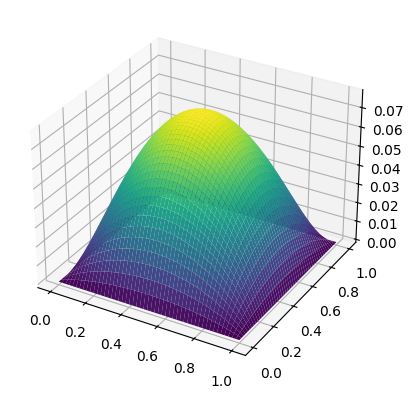

In [15]:
ax = plt.figure().add_subplot(111, projection = '3d')
ax.plot_surface(*solve_bratu(1.0), cmap='viridis')

(4 points) Conduct bifurcation analysis for the Bratu problem. So, you need to construct two plots:
   1. $\lambda$ vs. determinant of the Jacobian matrix
   2. $\lambda$ vs. $\|u\|_\infty$

In [16]:
def try_lambdas(lambdas: np.ndarray):
    deth, detg, normu = [], [], []

    results = joblib.Parallel(n_jobs = -1)(
        joblib.delayed(solve_bratu_with_stats)(lambd, verbose = False)
        for lambd in tqdm(lambdas)
    )
    for (_, _, _, Fh, Fg, norm_u) in results:
        deth.append(np.linalg.norm(Fh))
        detg.append(np.linalg.norm(Fg))
        normu.append(np.linalg.norm(norm_u))

    fig, axes = plt.subplots(1, 3, figsize = (14, 4))

    axes[0].set_title("$\det(F_h)$ vs $\lambda$")
    axes[0].plot(lambdas, deth)

    axes[1].set_title("$\det(F_g)$ vs $\lambda$")
    axes[1].plot(lambdas, detg)

    axes[2].set_title("$||u||$ vs $\lambda$")
    axes[2].plot(lambdas, normu)

  0%|          | 0/100 [00:00<?, ?it/s]

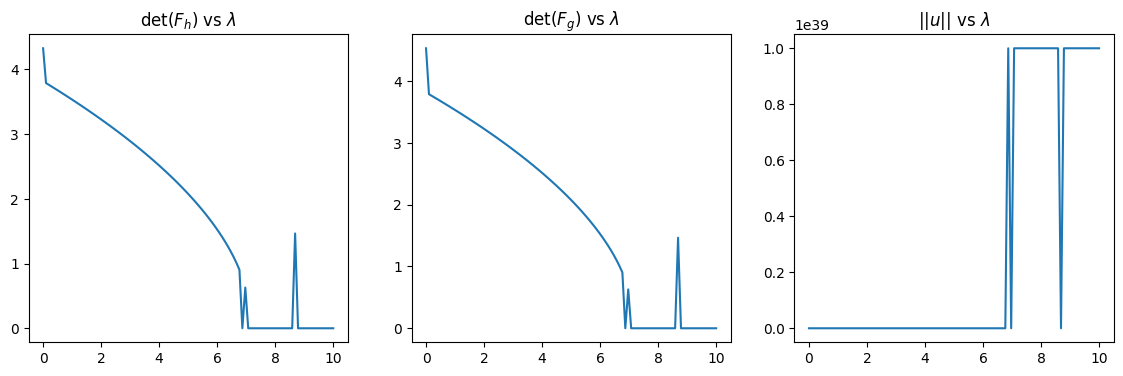

In [17]:
try_lambdas(np.linspace(0, 10, 100))

The bifurcation is indeed around 7.

Iteration 1: 39.542105949504446
Iteration 2: 5.605683598647805
Iteration 3: 1.6816789789210163
Iteration 4: 0.2809958177081083
Iteration 5: 6.761826890443742
Iteration 6: 1.4968496699086633
Iteration 7: 0.08466798061906955
Iteration 8: 0.004673454320640279
Iteration 9: 0.00025761691831648954
Iteration 10: 1.419968381838723e-05
Iteration 11: 7.826739242799741e-07
Iteration 12: 4.3140942792353e-08
Iteration 13: 2.3786264198618297e-09
Converged in 14 iterations


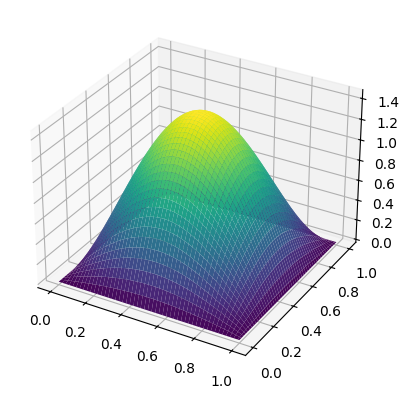

In [23]:
ax = plt.figure().add_subplot(111, projection = '3d')
ax.plot_surface(*solve_bratu(7.0, resolution = 100, max_iter = 25, newton_max_iter = 20), cmap='viridis')

Iteration 1: 37.601215689595946
Iteration 2: 1.2317908490289542
Iteration 3: 732.1663581981137
Iteration 4: 848.9893434570392
Iteration 5: 1151.0928128041808
Iteration 6: 1745.4138576959197
Iteration 7: 4.4624627782905275
Iteration 8: 0.031788853110118934
Iteration 9: 0.0004956237201704759
Iteration 10: 1.1255670549529129e-05
Iteration 11: 2.6526768395743163e-07
Iteration 12: 6.267508882807151e-09
Converged in 13 iterations


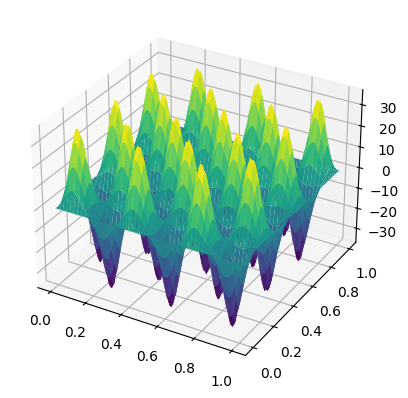

In [24]:
ax = plt.figure().add_subplot(111, projection = '3d')
ax.plot_surface(*solve_bratu(7.0097, resolution = 100, max_iter = 25, newton_max_iter = 20), cmap='viridis')

7.0097 is the last value where the picture looks reasonable. Going further, the values explode and there is nothing to see. This is the indicator of the bifurcation.

Iteration 1: 38.70346348319967
Iteration 2: 2.1326757237194123
Iteration 3: 3.768141523520543e+21
Iteration 4: 9.900000000000048e+37
Converged in 5 iterations


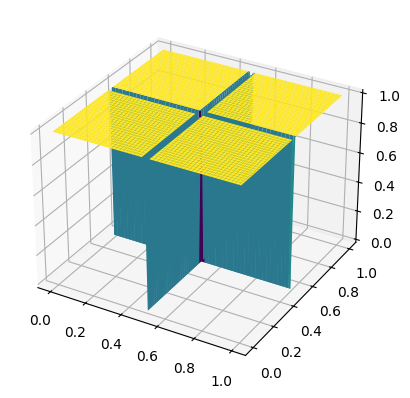

In [25]:
ax = plt.figure().add_subplot(111, projection = '3d')
ax.plot_surface(*solve_bratu(7.0098, resolution = 100, max_iter = 25, newton_max_iter = 20), cmap='viridis')